In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

sns.set_style("darkgrid")

ELOS = list(range(800, 2200, 100))
FEATURES = ['delta', 'fragility_score', 'variance']

In [2]:
df = pd.read_parquet("../data/stats_dataset.parquet")
df.tail()

,fen,next_move,games_count,global_avg_elo,global_winrate,engine_move,delta,fragility_score,variance,group_count_800,...,historical_best_1900,is_historical_best_1900,group_count_2000,winrate_2000,historical_best_2000,is_historical_best_2000,group_count_2100,winrate_2100,historical_best_2100,is_historical_best_2100
364,rnbqkb1r/pp3ppp/4pn2/3p2B1/3P4/2N2N2/PPP2PPP/R...,f8e7,1026,1558.558480,0.513645,b8c6,0.319615,0.346732,-0.202414,68.0,...,[f8e7],True,330,0.530303,[f8e7],True,189,0.550265,[f8e7],True
365,rnbqkb1r/ppp2Npp/8/3np3/2B5/8/PPPP1PPP/RNBQK2R...,e8f7,607,1423.490939,0.220758,e8f7,-0.766815,-0.940866,-0.023852,94.0,...,[e8f7],True,109,0.229358,[e8f7],True,64,0.234375,[e8f7],True
366,rnbqkb1r/ppp2pp1/3p1n1p/8/2BNP3/2N5/PPP2PPP/R1...,f8e7,615,1600.004878,0.481301,f8e7,0.717089,-0.588681,-0.172037,22.0,...,[f8e7],True,222,0.454955,[f8e7],True,134,0.447761,[f8e7],True
367,rnbqkb1r/ppp2pp1/3p1n1p/8/2BNP3/2N5/PPP2PPP/R1...,f8e7,1172,1666.412116,0.448805,f8e7,0.187123,-0.588681,-0.156246,15.0,...,[f8e7],True,575,0.453913,[f8e7],True,377,0.442971,[f8e7],True
368,rnbqkbnr/pp3ppp/4p3/3pP3/3P4/5N2/PP3PPP/RNBQKB...,b8c6,523,1618.799235,0.468451,f8b4,0.240120,-0.521299,-0.195704,34.0,...,[b8c6],True,212,0.476415,[b8c6],True,149,0.436242,[b8c6],True


In [3]:
importances = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    target = f'is_historical_best_{elo}'
    subset = df.dropna(subset=FEATURES + [target])
    X = subset[FEATURES]
    y = subset[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=1, test_size=0.25
    )

    model = XGBClassifier(eval_metric='logloss')
    model.fit(X_train, y_train)
    importances[f'elo_{elo}'] = model.feature_importances_

importances

,elo_800,elo_900,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800,elo_1900,elo_2000,elo_2100
delta,0.356864,0.397973,0.368539,0.402090,0.381881,0.352355,0.400095,0.38460,0.415766,0.443825,0.424504,0.357231,0.427879,0.406863
fragility_score,0.325317,0.262139,0.302526,0.311694,0.320330,0.338740,0.332457,0.31017,0.292718,0.277160,0.277166,0.273431,0.279670,0.282259
variance,0.317819,0.339888,0.328936,0.286216,0.297789,0.308905,0.267448,0.30523,0.291517,0.279014,0.298330,0.369337,0.292451,0.310877


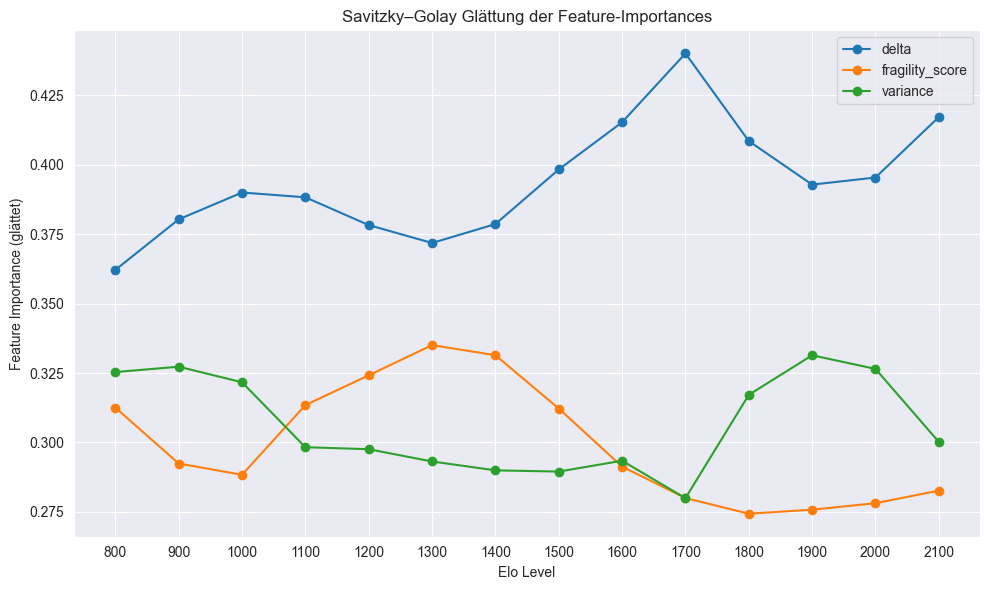

In [4]:
plt.figure(figsize=(10, 6))

for feature in FEATURES:
    y = importances.loc[feature, importances.columns].values
    # window_length muss ungerade und <= len(ELOS) sein
    y_smooth = savgol_filter(y, window_length=5, polyorder=2)
    plt.plot(ELOS, y_smooth, marker='o', label=feature)

plt.xlabel("Elo Level")
plt.ylabel("Feature Importance (glättet)")
plt.title("Savitzky–Golay Glättung der Feature-Importances")
plt.xticks(ELOS)
plt.legend()
plt.tight_layout()
plt.show()

## Score hinzufügen und recommendation machen

In [6]:
for elo in ELOS:
    score_col = f"score_{elo}"
    rec_col = f"recommended_move_{elo}"
    is_best_col = f"is_best_{elo}"
    is_engine_col = f"is_engine_best_{elo}"
    elo_col = f"elo_{elo}"
    group_count_col = f"group_count_{elo}"
    hist_col = f"historical_best_{elo}"

    # Assign score
    df[score_col] = (
            importances.loc["delta", elo_col] * df["delta"] +
            importances.loc["fragility_score", elo_col] * df["fragility_score"] +
            importances.loc["variance", elo_col] * df["variance"]
    )

    # Determine the recommended move per FEN based on the score
    idx_best_score = df.groupby("fen")[score_col].idxmax().dropna().astype(int)
    recommended = df.loc[idx_best_score, ["fen", "next_move"]].set_index("fen")["next_move"]
    df[rec_col] = df["fen"].map(recommended)

    # Compare recommendations and engine move with historical best
    df[is_best_col] = df.apply(lambda r: r[rec_col] in r[hist_col], axis=1).astype('boolean')
    df[is_engine_col] = df.apply(lambda r: r["engine_move"] in r[hist_col], axis=1).astype('boolean')

    # Mask out positions with too few samples or missing data
    invalid_mask = (
            (df[group_count_col] < 20) |
            (df[group_count_col].isna())
    )
    df.loc[invalid_mask, [is_best_col, is_engine_col]] = pd.NA

    # Exclude rows where engine move is not among the observed moves for that position
    valid_moves_per_fen = df.groupby("fen")["next_move"].agg(set).to_dict()
    df["engine_valid_move"] = df.apply(
        lambda row: row["engine_move"] in valid_moves_per_fen.get(row["fen"], set()),
        axis=1
    )
    df.loc[~df["engine_valid_move"], [is_engine_col]] = pd.NA
    df.drop(columns="engine_valid_move", inplace=True)

In [7]:
df.head()

,fen,next_move,games_count,global_avg_elo,global_winrate,engine_move,delta,fragility_score,variance,group_count_800,...,is_best_1900,is_engine_best_1900,score_2000,recommended_move_2000,is_best_2000,is_engine_best_2000,score_2100,recommended_move_2100,is_best_2100,is_engine_best_2100
0,r1b1kbnr/pp2pppp/2n5/3q4/8/2N2N2/PP1P1PPP/R1BQ...,d5d8,691,1881.942113,0.438495,d5d8,0.081130,0.590421,-0.173218,7.0,...,True,True,0.149179,d5d8,True,True,0.145811,d5d8,True,True
1,r1bQkbnr/ppp2ppp/8/4p3/4P3/8/PPP2PPP/RNB1KB1R ...,e8d8,5146,1612.776720,0.421298,e8d8,0.319615,-0.978277,-0.202019,360.0,...,True,True,-0.195919,e8d8,True,True,-0.208891,e8d8,True,True
2,r1bk1bnr/ppp2ppp/8/4p3/2B1P3/8/PPP2PPP/RNB1K2R...,c8e6,808,1646.288366,0.433168,g8f6,-3.045669,-0.970231,0.031976,46.0,...,False,<NA>,-1.565171,f7f6,True,<NA>,-1.503087,f7f6,False,<NA>
3,r1bk1bnr/ppp2ppp/8/4p3/2B1P3/8/PPP2PPP/RNB1K2R...,f7f6,793,1739.867591,0.419924,g8f6,-0.369341,-0.951457,-0.198768,17.0,...,False,<NA>,-0.482257,f7f6,True,<NA>,-0.480621,f7f6,False,<NA>
4,r1bk1bnr/ppp2ppp/8/4p3/4P3/8/PPP2PPP/RNB1KB1R ...,b1c3,1746,1614.620275,0.490836,f1c4,-0.422338,-0.943411,-0.198194,105.0,...,True,True,-0.502515,f1c4,True,True,-0.499734,f1c4,True,True


In [8]:
df.to_parquet("../data/recommendation_dataset.parquet", index=False)
print("✅ Saved enriched dataset to 'data/recommendation_dataset.parquet'")

✅ Saved enriched dataset to 'data/recommendation_dataset.parquet'
